# KNN Project
## Group Members:
- **Benjamin Nelson**: Wrote the bulk of the code for our KNN algorithm
- **Cole Clodgo**: Wrote the markdown explanations
- **Kaiden McCready**: Handled getting the datasets in and doing preprocessing of the data
- **Kosei Yamaguchi**: Ran experiments and tested the code
## Project Explanation
K Nearest Neighbors is a machine learning algorithm that classifies data points based on the labels of nearby points. Our algorithm takes data points, an unlabeled point, and a value for k as inputs. It then computes the distance between the unlabeled point and every labeled data point. We then look at the k points that are closest to the unlabeled point, and whichever label has a simple majority is assigned to the unlabeled point.
## Data
We run our KNN algorithm on two different datasets. These datasets allow us to test our algorithm using real data with different dimensions. 
### Fisher Iris Data
The first dataset is the Fisher Iris Data set. This dataset contains 150 samples of iris flowers. These samples are categorized into 4 species and have 4 numeric attributes. We use these attributes to categorize an unlabeled sample into one of the four species by using the numeric values for the attributes to find the "distance" between the samples. We then categorize the new sample by using the other samples' species as their labels.

In [ ]:
# ***
# Prerequisites:
# pip install ucimlrepo
# ***

from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
x = iris.data.features 
y = iris.data.targets 

# from 'cleanup.ipynb'
iris_training_set = pd.read_csv("iris_example_project/Iris_training_data.csv").to_numpy()

def adapt_for_bens_LoL(numpy_array):
    n_parameters = len(numpy_array[0]) - 1
    # magic box that turns [[5], ...] into [[[4], [1]], ...]. probably slow when working with big datasets.
    return [[row[:n_parameters].tolist(), row[n_parameters]] for row in numpy_array] 

iris_training_set = adapt_for_bens_LoL(iris_training_set)
print(iris_training_set)


[[[0.5833333333333334, 0.2916666666666667, 0.7288135593220338, 0.75], 'Iris-virginica'], [[0.5555555555555555, 0.3333333333333332, 0.6949152542372881, 0.5833333333333334], 'Iris-virginica'], [[0.1944444444444444, 0.4166666666666666, 0.1016949152542373, 0.0416666666666666], 'Iris-setosa'], [[0.5833333333333334, 0.5, 0.7288135593220338, 0.9166666666666666], 'Iris-virginica'], [[0.4166666666666666, 0.3333333333333332, 0.6949152542372881, 0.9583333333333331], 'Iris-virginica'], [[0.2777777777777777, 0.7083333333333333, 0.0847457627118644, 0.0416666666666666], 'Iris-setosa'], [[0.5833333333333334, 0.3333333333333332, 0.7796610169491525, 0.8333333333333334], 'Iris-virginica'], [[0.1944444444444444, 0.6666666666666666, 0.0677966101694915, 0.0416666666666666], 'Iris-setosa'], [[0.4444444444444445, 0.4166666666666666, 0.6949152542372881, 0.7083333333333334], 'Iris-virginica'], [[1.0, 0.7499999999999998, 0.9152542372881356, 0.7916666666666666], 'Iris-virginica'], [[0.25, 0.2916666666666667, 0.49

In [86]:
import math
#import string

#data input as [[[values],[lables]],[[values1],[lables1]],...]
def KNN(data, pointToFind, k):
  #find Closests
  #closest[0] = dist, [1] = value, [2] = labels, [3] = weight
  
  Closest = {"Dist": [], "Value": [], "Labels": [], "Weight": []}
  for Point in data:
    dist = 0
    for variableId in range(len(Point[0])):
      dist += ((pointToFind[variableId]-Point[0][variableId])**2)
    dist = math.sqrt(dist)
    
    #add to Closest
    if len(Closest["Dist"]) >= k:
      compareItem = max(Closest["Dist"])
      if compareItem > dist:
        #get indexs and choose the first one
        index = Closest["Dist"].index(compareItem)
        Closest["Dist"][index] = dist
        Closest["Value"][index] = Point[0]
        Closest["Labels"][index] = Point[1]
        Closest["Weight"][index] = [0]
    else:
      Closest["Dist"].append(dist)
      Closest["Value"].append(Point[0])
      Closest["Labels"].append(Point[1])
      Closest["Weight"].append([0])

  #Value fix/weighting
  MinimumVal = min(Closest["Dist"])
  MaximumVal = max(Closest["Dist"])

  #Comparaisons[0] = labels, Comparaisons[1] = total weight
  Comparaisons = {"Labels": [], "Weights": []}
  for itemIndex in range(len(Closest["Dist"])):
    value = (Closest["Dist"][itemIndex] - MinimumVal)
    if (MaximumVal-MinimumVal) != 0:
      value = value/(MaximumVal-MinimumVal)
    value = 1 - value
    Closest["Weight"][itemIndex] = value
  
    if Closest["Labels"][itemIndex] not in Comparaisons["Labels"]:
      Comparaisons["Labels"].append(Closest["Labels"][itemIndex]) #WARNING: I don't know why but 0 works here. If there is more than one label per thing it doesn't work
      Comparaisons["Weights"].append(Closest["Weight"][itemIndex])
       
    else:
      CompIndex = Comparaisons["Labels"].index(Closest["Labels"][itemIndex])
      Comparaisons["Weights"][CompIndex] += Closest["Weight"][itemIndex]
    
  
  
  retLabel = Comparaisons["Labels"][Comparaisons["Weights"].index(max(Comparaisons["Weights"]))] #from labels, the one with the highest weighted score

  return retLabel

In [87]:
data = [[[8.0,27.0,0.0,9.4],["cool"]],[[89.0,27.0,1.0,69.4],["rad"]],[[87.0,27.0,0.0,97.4],["cool"]],[[90.0,90.0,3.0,25.4],["uncool"]],[[95.0,23.0,3.0,80.4], ["rad"]]]
point = [105.0,90.0,2.0,85.4]

KNN(data, point, 3)

['uncool']

In [88]:
# [-1.3807270877331406,0.3367202847780191,-1.3934698549528162,-1.3085928194379575] -> Iris-setosa as a test case.
iris_test_point = [-1.3807270877331406,0.3367202847780191,-1.3934698549528162,-1.3085928194379575]
KNN(data=iris_training_set, pointToFind=iris_test_point, k=3)


'Iris-setosa'

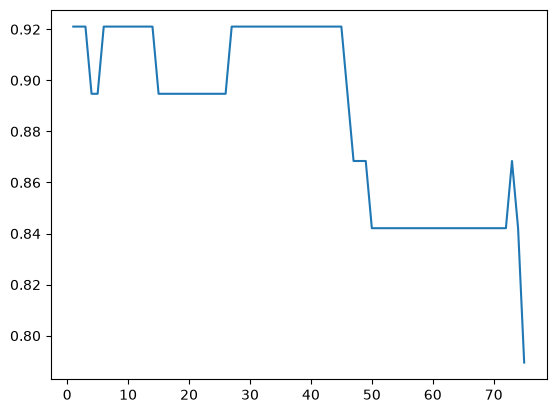

In [ ]:
iris_evaluating_set = pd.read_csv("iris_example_project/Iris_testing_data.csv")

# format test points to ben's LoL
eval_points = iris_evaluating_set.drop(columns="Species").values.tolist()

# evaluate k options + accuracies
evaluations = pd.DataFrame(columns=["k", "accuracy"])

# check k 1 - 75
for k in range(1, 76):    

    # run the model on each point in the test set (eval_points)
    iris_evaluating_set["Predicted"] = [KNN(iris_training_set, point, k) for point in eval_points]
    # check to see if each prediction was correct
    iris_evaluating_set["Correct?"] = iris_evaluating_set["Species"] == iris_evaluating_set["Predicted"]
    # get the % of accurate predictions
    accuracy = iris_evaluating_set["Correct?"].mean()
    evaluations = pd.concat([evaluations, pd.DataFrame([{'k': k, 'accuracy': accuracy}])], ignore_index=True)
    # print(f"k = {k}; accuracy = {accuracy.round(5)}")

_ = plt.plot(evaluations["k"], evaluations["accuracy"]) # this apparently stops the class from printing randomly when displaying the plot